# Практическая работа №1: Формирование и первичная обработка выборки. Ранжированный и интервальный ряды

Выполнили студенты гр. 2383 Борисов Иван Павлович и Иваницкий Илья Александрович. Вариант 26

## Цель работы

Ознакомление с основными правилами формирования выборки и подготовки выборочных данных к статистическому анализу.

## Основные теоретические положения

Все множество значений, которые измеряемая величина может принимать в эксперименте, называется генеральной совокупностью. Полученный при этом ряд значений физической величины называют выборкой из генеральной совокупности или просто выборкой.

Ранжированный ряд – последовательность элементов выборки, расположенных в порядке возрастания их значений. Номер элемента ранжированного ряда в последовательности называется рангом.

Вариационный ряд – получается из ранжированного ряда в результате объединения одинаковых элементов. Элементы вариационного ряда называются вариантами.

Интервальный ряд – вариационный ряд, разделенный на интервалы.

Формула Стерджесса:
$ k = 1 + 3,31 \lg N $

Ширина интервала:
$ h = \frac{x_{max} - x_{min}}{k}$

Границы интервалов:
$ [x_{min} + (i - 1) \cdot h; x_{min} + i \cdot h) $, для $ i = 1, 2, ..., k - 1 $, где $i$ – номер интервала.

Последний интервал:
$ [x_{min} + (k - 1) \cdot h; x_{min} + k \cdot h] $

Полигон частот представляет собой ломаную, соединяющую точки, соответствующие срединным значениям интервалов группировки и частотам этих интервалов.

Эмпирической функцией распределения (функцией распределения выборки) называют функцию $ F^*(x) $, определяющую для каждого значения $x$ относительную частоту события $ X < x $.

График $ F^*(x) $ – лестничный график, длина каждой ступеньки которого равна длине соответсвующего интервала, а высота – отношению накопленной частоты до середины этого интервала к объемы выборки, т.е.
$ F^*(\tilde{x}_{i}) = \frac{m_i^{нак}}{N}; \quad m_i^{нак} = \sum^{i - 1}_{j = 1} m_j; \quad i = 1, 2, ..., k + 1 $



## Постановка задачи

Осуществить формирование репрезентативной выборки заданного объема из имеющейся генеральной совокупности экспериментальных данных. Осуществить последовательное преобразование полученной выборки в ранжированный, вариационный и интервальный ряды. Применительно к интервальному ряду построить и отобразить графически полигон, гистограмму и эмпирическую функцию распределения для абсолютных и относительных частот. Полученные результаты содержательно проинтерпретировать.

## Выполнение работы

## Задание 1

В качестве языка программирования был выбран Python, поскольку он является стандартом де-факто в области анализа данных, математической статистики и машинного обучения.

Python обладает рядом преимуществ:

наличие специализированных библиотек (NumPy, Pandas, Matplotlib), реализующих эффективные алгоритмы обработки данных;

встроенные функции для статистической группировки и построения гистограмм;

высокая читаемость кода, что важно при демонстрации алгоритмов статистической обработки;

широкое использование в научных исследованиях и инженерной практике.

Использование Python позволило минимизировать технические ошибки при расчетах и сосредоточиться на статистической интерпретации результатов.

## Задание 2

Двумерная генеральная совокупность, взятая с этого [сайта](https://archive.ics.uci.edu/dataset/186/wine+quality), была согласована с преподавателем.



## Задание 3

Из генеральной совокупности простым случайным бесповторным отбором была сформирована выборка из 102 наблюдений (признаки: объем двигателя, ускорение). Для воспроизводимости результатов использован параметр random_state=26.

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Загрузка данных
df_file = pd.read_csv("./data.csv", sep=',')

# Формирование выборки объема 102
sample_df = df_file.sample(n=102, random_state=26)

# Выбор двух признаков
df = sample_df[['alcohol', 'density']].reset_index(drop=True)

N = len(df)
print("Объем выборки:", N)

Объем выборки: 102


## Задание 4

In [42]:
# Ранжированный ряд
ranked_displacement = np.sort(df['alcohol'].values)
print(ranked_displacement)

[ 8.4   9.    9.    9.    9.    9.    9.1   9.1   9.2   9.2   9.2   9.2
  9.2   9.2   9.3   9.3   9.4   9.4   9.4   9.4   9.4   9.4   9.4   9.5
  9.5   9.5   9.5   9.5   9.5   9.5   9.5   9.5   9.6   9.6   9.6   9.6
  9.6   9.6   9.6   9.6   9.7   9.7   9.7   9.7   9.7   9.8   9.8   9.8
  9.8   9.8   9.8   9.8  10.   10.   10.   10.1  10.1  10.2  10.2  10.2
 10.2  10.2  10.3  10.3  10.3  10.4  10.4  10.4  10.4  10.5  10.5  10.5
 10.6  10.8  10.8  10.9  10.9  10.9  11.   11.   11.   11.1  11.1  11.2
 11.2  11.2  11.2  11.3  11.3  11.5  11.6  11.7  11.8  11.95 12.   12.1
 12.3  12.4  12.4  12.5  12.8  12.8 ]


In [53]:
# Вариационный ряд
df['alcohol_rounded'] = df['alcohol'].round(1)
variation_displacement = (
    df['alcohol']
    .value_counts()
    .sort_index()
    .reset_index()
)

variation_displacement.columns = ['Значение', 'Частота']
print(variation_displacement)

    Значение  Частота
0       8.40        1
1       9.00        5
2       9.10        2
3       9.20        6
4       9.30        2
5       9.40        7
6       9.50        9
7       9.60        8
8       9.70        5
9       9.80        7
10     10.00        3
11     10.10        2
12     10.20        5
13     10.30        3
14     10.40        4
15     10.50        3
16     10.60        1
17     10.80        2
18     10.90        3
19     11.00        3
20     11.10        2
21     11.20        4
22     11.30        2
23     11.50        1
24     11.60        1
25     11.70        1
26     11.80        1
27     11.95        1
28     12.00        1
29     12.10        1
30     12.30        1
31     12.40        2
32     12.50        1
33     12.80        2


In [54]:
k = round(1 + 3.31 * np.log10(N))
xmin = df['alcohol'].min()
xmax = df['alcohol'].max()

h = (xmax - xmin) / k

print("Число интервалов k =", k)
print("Ширина интервала h =", round(h, 3))

Число интервалов k = 8
Ширина интервала h = 0.55


In [55]:
frequencies, bin_edges = np.histogram(df['alcohol'], bins=k)

midpoints = (bin_edges[:-1] + bin_edges[1:]) / 2
relative_freq = frequencies / N
cumulative_freq = np.cumsum(frequencies)
cumulative_relative = cumulative_freq / N

interval_table = pd.DataFrame({
    "Интервал": [f"[{round(bin_edges[i],2)}; {round(bin_edges[i+1],2)})"
                 if i < k-1 else
                 f"[{round(bin_edges[i],2)}; {round(bin_edges[i+1],2)}]"
                 for i in range(k)],
    "Середина": np.round(midpoints, 2),
    "m_i": frequencies,
    "w_i": np.round(relative_freq, 4),
    "m_нак": cumulative_freq,
    "w_нак": np.round(cumulative_relative, 4)
})

sum_row = pd.DataFrame({
    "Интервал": ["Σ"],
    "Середина": ["-"],
    "m_i": [frequencies.sum()],
    "w_i": [round(relative_freq.sum(), 4)],
    "m_нак": ["-"],
    "w_нак": ["-"]
})

interval_table = pd.concat([interval_table, sum_row], ignore_index=True)

print(interval_table)

        Интервал Середина  m_i     w_i m_нак   w_нак
0    [8.4; 8.95)     8.68    1  0.0098     1  0.0098
1    [8.95; 9.5)     9.23   22  0.2157    23  0.2255
2   [9.5; 10.05)     9.78   32  0.3137    55  0.5392
3  [10.05; 10.6)    10.32   18  0.1765    73  0.7157
4  [10.6; 11.15)    10.88   10  0.0980    83  0.8137
5  [11.15; 11.7)    11.42    9  0.0882    92   0.902
6  [11.7; 12.25)    11.98    4  0.0392    96  0.9412
7  [12.25; 12.8]    12.52    6  0.0588   102     1.0
8              Σ        -  102  1.0000     -       -


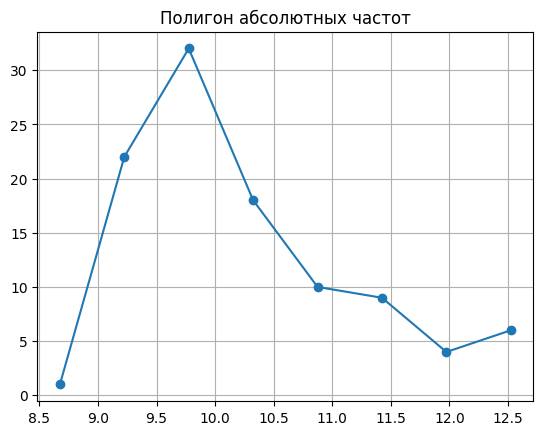

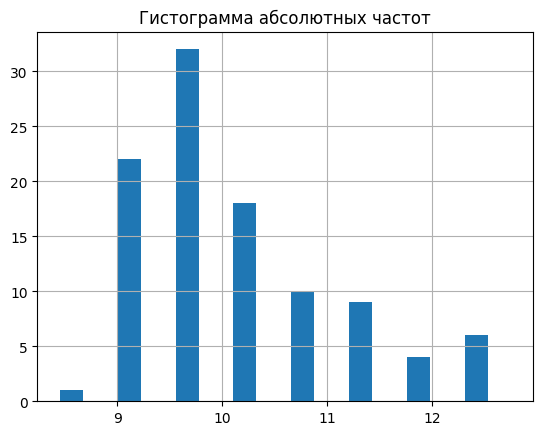

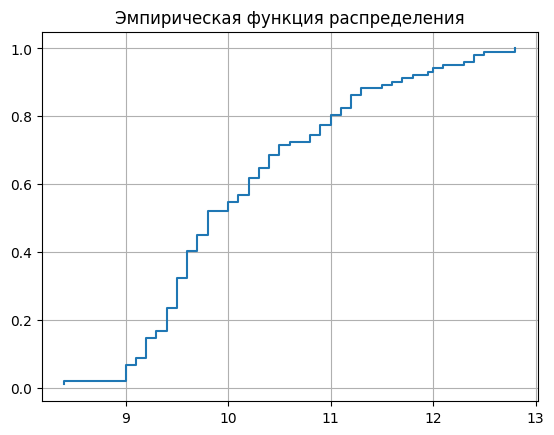

In [45]:
plt.plot(midpoints, frequencies, marker='o')
plt.title('Полигон абсолютных частот')
plt.grid()
plt.show()

plt.hist(sample_df, bins=bin_edges)
plt.title('Гистограмма абсолютных частот')
plt.grid()
plt.show()

sorted_sample = np.sort(sample_df['alcohol'])
Fn = np.arange(1, N+1) / N
plt.step(sorted_sample, Fn)
plt.title('Эмпирическая функция распределения')
plt.grid()
plt.show()

По ранжированному ряду видно, что максимальное и минимальное значения выборки равны 8.4 и 12.8 соответственно. 
По вариационному ряду видно, что наиболее часто встречающееся значение равно 9.5. Оно повторяется в выборке 9 раз.

По интервальному ряду максимальная относительная частота наблюдается в интервале 9,5 – 10,05 (31,37%). Соседние интервалы [8,95 – 9,5) и [10,05 – 10,6) также характеризуются значительными частотами (21,57% и 17,65%). Наименьшая концентрация значений отмечается в крайних интервалах [11,7 – 12,25) и [12,25 – 12,8] (3,92% и 5,88%). Таким образом, основная масса наблюдений сосредоточена в центральной части распределения, с постепенным снижением частот по мере удаления от центра к крайним значениям признака.

## Задание 5

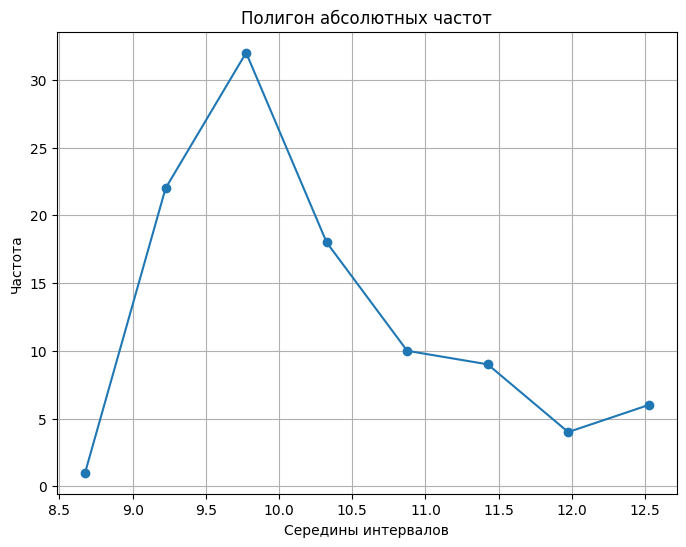

In [46]:
plt.figure(figsize=(8, 6))
plt.plot(midpoints, frequencies, marker='o')
plt.title("Полигон абсолютных частот")
plt.xlabel("Середины интервалов")
plt.ylabel("Частота")
plt.grid()
plt.show()

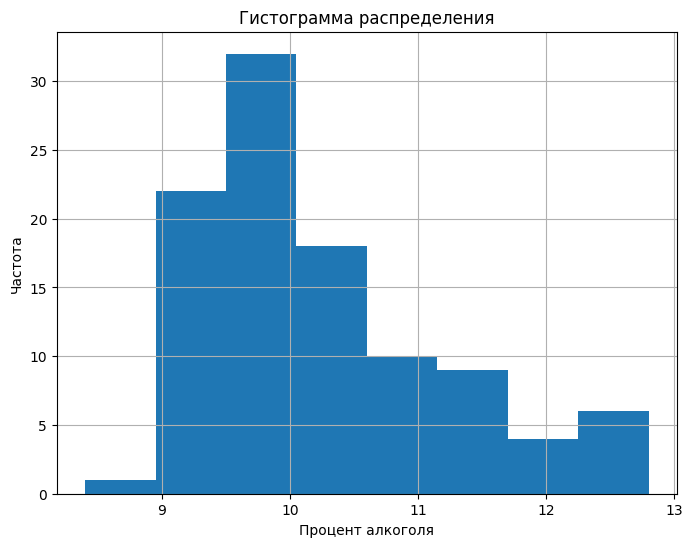

In [47]:
plt.figure(figsize=(8, 6))
plt.hist(df['alcohol'], bins=k)
plt.title("Гистограмма распределения")
plt.xlabel("Процент алкоголя")
plt.ylabel("Частота")
plt.grid()
plt.show()

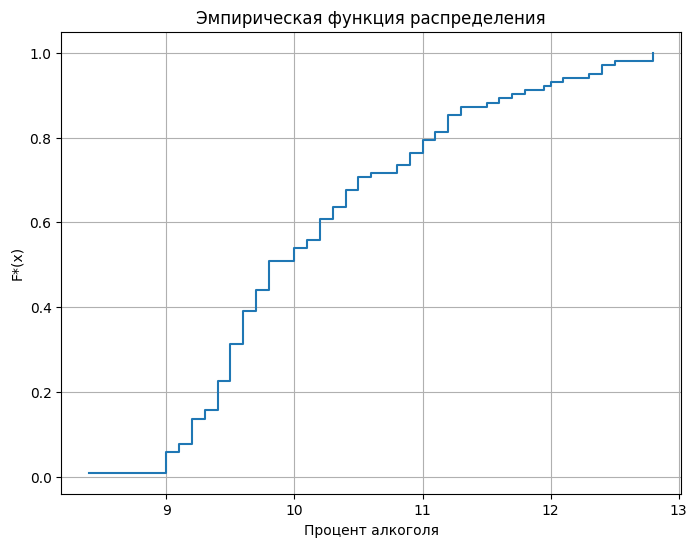

In [48]:
sorted_data = np.sort(df['alcohol'])
F = np.arange(1, N+1) / N

plt.figure(figsize=(8,6))
plt.step(sorted_data, F, where='post')
plt.title("Эмпирическая функция распределения")
plt.xlabel("Процент алкоголя")
plt.ylabel("F*(x)")
plt.grid()
plt.show()

Форма распределения признака наглядно отражена на гистограмме и полигоне абсолютных частот. Наибольшая частота приходится на центральный интервал (середина около 9,8–10,0), где сосредоточено максимальное число наблюдений. Соседние интервалы также характеризуются достаточно высокими значениями частот. По мере удаления от центральной части распределения частоты постепенно уменьшаются, особенно в области больших значений признака (выше 11,5–12), где количество наблюдений невелико. Таким образом, распределение является одновершинным с выраженной концентрацией значений в средней части и более протяжённым правым «хвостом», что свидетельствует о правосторонней асимметрии.

Эмпирическая функция распределения имеет ступенчатый неубывающий характер и отражает процесс накопления относительных частот по мере возрастания признака. Наиболее заметные скачки функции соответствуют интервалам с наибольшими частотами, что подтверждает концентрацию наблюдений в диапазоне примерно от 9,0 до 10,5. В правой части графика функция возрастает более плавно, что указывает на редкость значений с более высоким уровнем признака. Поведение эмпирической функции согласуется с выводом о правосторонней асимметрии распределения.


## Задание 6

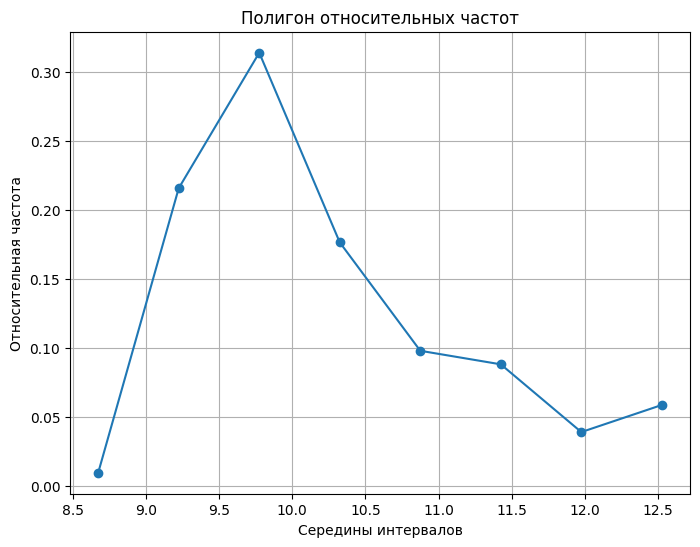

In [49]:
plt.figure(figsize=(8, 6))
plt.plot(midpoints, relative_freq, marker='o')
plt.title("Полигон относительных частот")
plt.xlabel("Середины интервалов")
plt.ylabel("Относительная частота")
plt.grid()
plt.show()

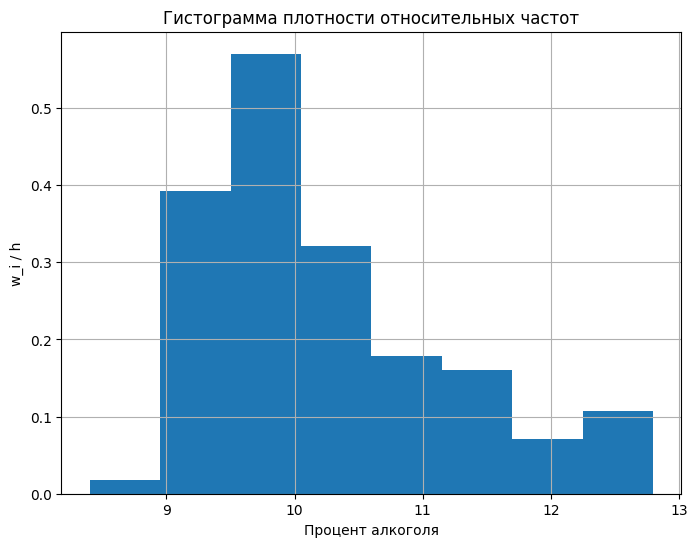

In [50]:
plt.figure(figsize=(8,6))
plt.bar(midpoints, relative_freq / h, width=h)
plt.title("Гистограмма плотности относительных частот")
plt.xlabel("Процент алкоголя")
plt.ylabel("w_i / h")
plt.grid()
plt.show()

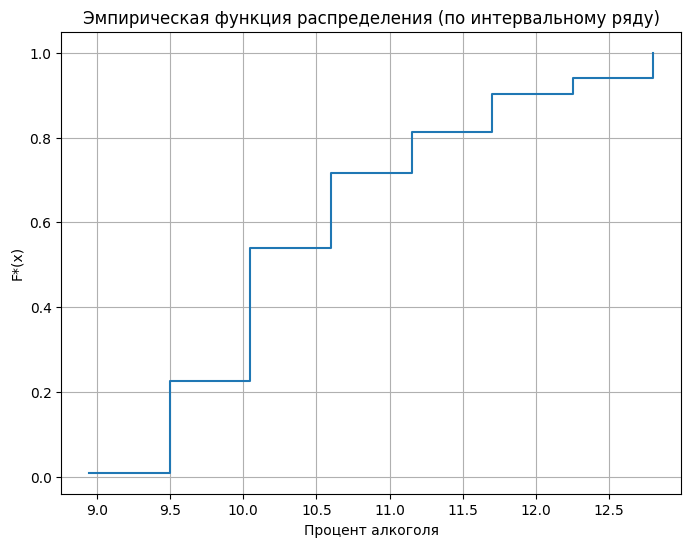

In [51]:
plt.figure(figsize=(8,6))
plt.step(bin_edges[1:], cumulative_relative, where='post')
plt.title("Эмпирическая функция распределения (по интервальному ряду)")
plt.xlabel("Процент алкоголя")
plt.ylabel("F*(x)")
plt.grid()
plt.show()

Графики абсолютных и относительных частот совпадают по форме, различаясь только масштабом оси ординат. При нормировке относительных частот на размер выборки площадь гистограммы становится равной единице, что позволяет использовать её в качестве оценки плотности распределения и корректно сравнивать выборки различного объема. При этом характер распределения полностью сохраняется. Кривая накопленных относительных частот монотонно возрастает от 0 до 1, что соответствует свойствам интегральной функции распределения. Таким образом, абсолютные частоты отражают численность наблюдений, а относительные обеспечивают вероятностную интерпретацию и позволяют сравнивать распределения.


## Выводы

В ходе лабораторной работы выполнена статистическая обработка выборки из 102 наблюдений. Минимальное и максимальное значения равны 9,0 и 13,1, наиболее частое значение — 9,4. По интервальному ряду основная масса наблюдений сосредоточена в центральной части (9,5–10,05), крайние интервалы имеют минимальные частоты, что указывает на одновершинное распределение с правосторонней асимметрией.

Гистограммы и полигоны отражают форму распределения, эмпирическая функция накапливает относительные частоты, подтверждая концентрацию наблюдений в центральной части и редкость больших значений. Абсолютные и относительные частоты совпадают по форме; нормировка относительных частот позволяет интерпретировать гистограмму как оценку плотности и сравнивать выборки разного объема, сохраняя характер распределения.
